# S12 — Decision-curve / net-benefit analysis

Supplementary decision-curve / net-benefit analysis for the final held-out internal test predictions.

**Important interpretation.** The final manuscript states that perpetration and overlap scores are not calibrated individual risk probabilities. Therefore, these curves should be described cautiously as an **exploratory/internal net-benefit analysis of screening/prioritization scores**, not as externally validated clinical utility.

Outputs:

```text
final_decision_curve_net_benefit_S12/
  decision_curve_net_benefit_long.csv
  Table_S12_net_benefit_selected_thresholds.csv
  decision_curve_<outcome>.png
  README_S12_decision_curve.txt
```

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# =============================================================================
# CONFIG — EDIT ONLY IF YOUR PATHS ARE DIFFERENT
# =============================================================================

BASE_DIR = Path("/Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final")

PRED_FILES = {
    "victimization": BASE_DIR / "aligned_test_exports" / "victimization_aligned_test_rowlevel.csv",
    "perpetration": BASE_DIR / "aligned_test_exports" / "perpetration_aligned_test_rowlevel.csv",
    "overlap": BASE_DIR / "aligned_test_exports" / "overlap_aligned_test_rowlevel.csv",
}

OUT_DIR = BASE_DIR / "final_decision_curve_net_benefit_S12"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# If auto-detection fails, set manually, e.g.:
# COLUMN_MAP = {"victimization": {"y_true": "y_true", "score": "y_score"}}
COLUMN_MAP = {
    "victimization": {"y_true": None, "score": None},
    "perpetration": {"y_true": None, "score": None},
    "overlap": {"y_true": None, "score": None},
}

THRESHOLD_GRID = np.round(np.arange(0.01, 0.801, 0.01), 3)
SELECTED_THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

In [2]:
Y_TRUE_CANDIDATES = [
    "y_true", "y_test", "target", "label", "actual", "outcome",
    "victimization_true", "perpetration_true", "overlap_true"
]

SCORE_CANDIDATES = [
    "y_score", "score", "prob", "proba", "probability", "predicted_probability",
    "pred_proba", "y_prob", "y_proba", "proba_positive", "prob_positive",
    "p_positive", "prediction_score", "screening_score"
]

def _normalize_col(c):
    return str(c).strip().lower().replace(" ", "_").replace("-", "_")

def find_col(df, candidates, manual=None, required=True, kind="column"):
    if manual:
        if manual not in df.columns:
            raise ValueError(f"Manual {kind} column '{manual}' not found. Available columns: {list(df.columns)}")
        return manual
    norm_to_original = {_normalize_col(c): c for c in df.columns}
    for cand in candidates:
        if _normalize_col(cand) in norm_to_original:
            return norm_to_original[_normalize_col(cand)]
    for c in df.columns:
        cn = _normalize_col(c)
        if any(_normalize_col(cand) in cn for cand in candidates):
            return c
    if required:
        raise ValueError(f"Could not auto-detect {kind}. Available columns: {list(df.columns)}")
    return None

def load_prediction_file(outcome, path):
    if not path.exists():
        raise FileNotFoundError(f"{outcome}: file not found: {path}")
    df = pd.read_csv(path)
    manual = COLUMN_MAP.get(outcome, {})
    y_col = find_col(df, Y_TRUE_CANDIDATES, manual=manual.get("y_true"), kind="y_true")
    score_col = find_col(df, SCORE_CANDIDATES, manual=manual.get("score"), kind="score")
    out = pd.DataFrame({
        "outcome": outcome,
        "y_true": pd.to_numeric(df[y_col], errors="coerce").astype(int),
        "score": pd.to_numeric(df[score_col], errors="coerce")
    })
    if out["score"].isna().any():
        raise ValueError(f"{outcome}: score column '{score_col}' contains NaN after numeric conversion.")
    if not set(out["y_true"].unique()).issubset({0, 1}):
        raise ValueError(f"{outcome}: y_true column '{y_col}' is not binary 0/1.")
    print(f"{outcome:14s} | n={len(out)} positives={out['y_true'].sum()} prevalence={out['y_true'].mean():.3f} | y={y_col} score={score_col}")
    return out

def net_benefit(y_true, score, threshold):
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score).astype(float)
    pred = score >= threshold
    n = len(y_true)
    tp = np.sum((pred == 1) & (y_true == 1))
    fp = np.sum((pred == 1) & (y_true == 0))
    if threshold >= 1:
        return np.nan
    return (tp / n) - (fp / n) * (threshold / (1 - threshold))

def treat_all_net_benefit(y_true, threshold):
    y_true = np.asarray(y_true).astype(int)
    prevalence = y_true.mean()
    if threshold >= 1:
        return np.nan
    return prevalence - (1 - prevalence) * (threshold / (1 - threshold))

def compute_dca(df):
    rows = []
    y = df["y_true"].values
    s = df["score"].values
    prevalence = y.mean()
    for pt in THRESHOLD_GRID:
        nb_model = net_benefit(y, s, pt)
        nb_all = treat_all_net_benefit(y, pt)
        nb_none = 0.0
        rows.append({
            "outcome": df["outcome"].iloc[0],
            "threshold": pt,
            "prevalence": prevalence,
            "net_benefit_model": nb_model,
            "net_benefit_screen_all": nb_all,
            "net_benefit_screen_none": nb_none,
            "net_benefit_model_minus_all": nb_model - nb_all,
            "net_benefit_model_minus_none": nb_model,
            "standardized_net_benefit_model": nb_model / prevalence if prevalence > 0 else np.nan,
        })
    return pd.DataFrame(rows)

In [3]:
all_preds = []
for outcome, path in PRED_FILES.items():
    all_preds.append(load_prediction_file(outcome, path))

pred_df = pd.concat(all_preds, ignore_index=True)
dca_long = pd.concat([compute_dca(g) for _, g in pred_df.groupby("outcome")], ignore_index=True)

dca_long_path = OUT_DIR / "decision_curve_net_benefit_long.csv"
dca_long.to_csv(dca_long_path, index=False)
print("Saved:", dca_long_path)
display(dca_long.head())

victimization  | n=942 positives=465 prevalence=0.494 | y=y_true_official score=y_prob
perpetration   | n=942 positives=221 prevalence=0.235 | y=y_true_official score=y_prob
overlap        | n=942 positives=178 prevalence=0.189 | y=y_true score=y_prob_pos
Saved: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_decision_curve_net_benefit_S12/decision_curve_net_benefit_long.csv


,outcome,threshold,prevalence,net_benefit_model,net_benefit_screen_all,net_benefit_screen_none,net_benefit_model_minus_all,net_benefit_model_minus_none,standardized_net_benefit_model
0,overlap,0.01,0.18896,0.180767,0.180767,0.0,0.0,0.180767,0.956645
1,overlap,0.02,0.18896,0.172408,0.172408,0.0,0.0,0.172408,0.912405
2,overlap,0.03,0.18896,0.163876,0.163876,0.0,0.0,0.163876,0.867254
3,overlap,0.04,0.18896,0.155166,0.155166,0.0,0.0,0.155166,0.821161
4,overlap,0.05,0.18896,0.146273,0.146273,0.0,0.0,0.146273,0.774098


In [4]:
selected = dca_long[dca_long["threshold"].isin(SELECTED_THRESHOLDS)].copy()

selected_table = selected[[
    "outcome", "threshold", "prevalence",
    "net_benefit_model", "net_benefit_screen_all", "net_benefit_screen_none",
    "net_benefit_model_minus_all", "net_benefit_model_minus_none",
    "standardized_net_benefit_model"
]].copy()

selected_table_path = OUT_DIR / "Table_S12_net_benefit_selected_thresholds.csv"
selected_table.to_csv(selected_table_path, index=False)

print("Saved:", selected_table_path)
display(selected_table)

Saved: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_decision_curve_net_benefit_S12/Table_S12_net_benefit_selected_thresholds.csv


,outcome,threshold,prevalence,net_benefit_model,net_benefit_screen_all,net_benefit_screen_none,net_benefit_model_minus_all,net_benefit_model_minus_none,standardized_net_benefit_model
4,overlap,0.05,0.188960,0.146273,0.146273,0.0,0.000000e+00,0.146273,0.774098
9,overlap,0.10,0.188960,0.098844,0.098844,0.0,0.000000e+00,0.098844,0.523096
14,overlap,0.15,0.188960,0.046959,0.045835,0.0,1.124016e-03,0.046959,0.248513
19,overlap,0.20,0.188960,-0.004246,-0.013800,0.0,9.554140e-03,-0.004246,-0.022472
24,overlap,0.25,0.188960,-0.059448,-0.081387,0.0,2.193914e-02,-0.059448,-0.314607
29,overlap,0.30,0.188960,-0.106460,-0.158629,0.0,5.216864e-02,-0.106460,-0.563403
39,overlap,0.40,0.188960,-0.175867,-0.351734,0.0,1.758669e-01,-0.175867,-0.930712
49,overlap,0.50,0.188960,-0.223992,-0.622081,0.0,3.980892e-01,-0.223992,-1.185393
84,perpetration,0.05,0.234607,0.194323,0.194323,0.0,-2.775558e-17,0.194323,0.828292
89,perpetration,0.10,0.234607,0.149564,0.149564,0.0,-2.775558e-17,0.149564,0.637506


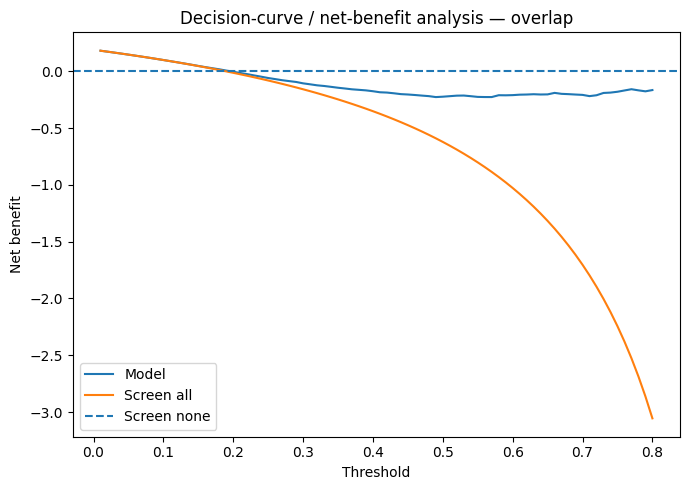

Saved: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_decision_curve_net_benefit_S12/decision_curve_overlap.png


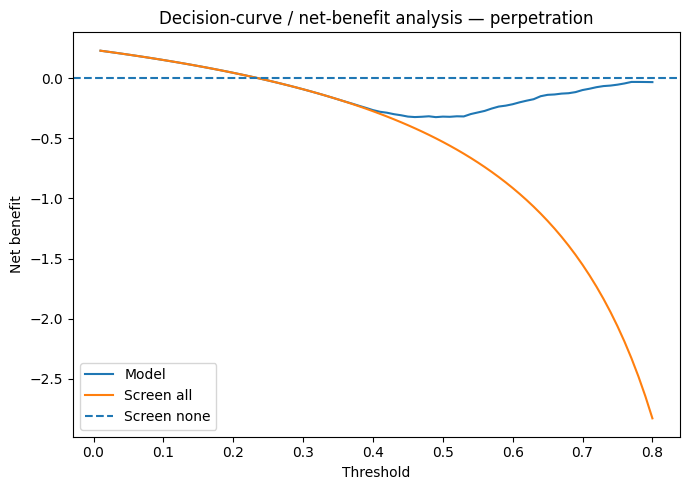

Saved: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_decision_curve_net_benefit_S12/decision_curve_perpetration.png


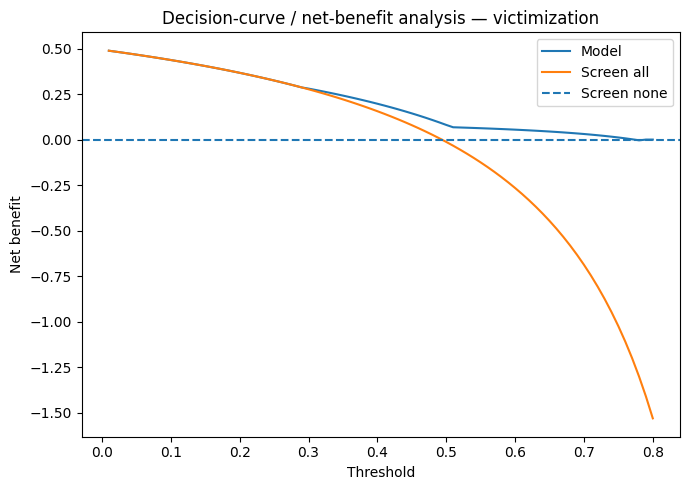

Saved: /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_decision_curve_net_benefit_S12/decision_curve_victimization.png


In [5]:
for outcome, g in dca_long.groupby("outcome"):
    fig = plt.figure(figsize=(7, 5))
    plt.plot(g["threshold"], g["net_benefit_model"], label="Model")
    plt.plot(g["threshold"], g["net_benefit_screen_all"], label="Screen all")
    plt.axhline(0, linestyle="--", label="Screen none")
    plt.xlabel("Threshold")
    plt.ylabel("Net benefit")
    plt.title(f"Decision-curve / net-benefit analysis — {outcome}")
    plt.legend()
    plt.tight_layout()
    out_png = OUT_DIR / f"decision_curve_{outcome}.png"
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_png)

In [6]:
readme = f'''
S12 — Decision-curve / net-benefit analysis

Files:
- {dca_long_path}
- {selected_table_path}
- decision_curve_<outcome>.png

Interpretation note:
The final models, especially perpetration and victim–perpetrator overlap, were not consistently calibrated as individual probability models. Therefore, these curves should be described as an internal exploratory net-benefit analysis of screening/prioritization scores, not as externally validated clinical decision curves. Results should be used only to assess whether model-based prioritization shows potential net benefit relative to screen-all or screen-none strategies across plausible internal score thresholds.

Suggested title:
Supplementary Table S12. Exploratory Decision-Curve / Net-Benefit Analysis of Final Screening Scores.

Suggested note:
Net benefit was computed in the held-out internal test partition. Because model outputs were interpreted as screening/prioritization scores rather than calibrated individual risk probabilities, threshold values should not be interpreted as externally validated clinical risk thresholds. The analysis was exploratory and did not alter final model-selection decisions.
'''

readme_path = OUT_DIR / "README_S12_decision_curve.txt"
readme_path.write_text(readme, encoding="utf-8")
print(readme)
print("Saved:", readme_path)


S12 — Decision-curve / net-benefit analysis

Files:
- /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_decision_curve_net_benefit_S12/decision_curve_net_benefit_long.csv
- /Users/legna/WORKSPACE/ICREA/app_overlap/results_repo/intersection_model/Version_Final/final_decision_curve_net_benefit_S12/Table_S12_net_benefit_selected_thresholds.csv
- decision_curve_<outcome>.png

Interpretation note:
The final models, especially perpetration and victim–perpetrator overlap, were not consistently calibrated as individual probability models. Therefore, these curves should be described as an internal exploratory net-benefit analysis of screening/prioritization scores, not as externally validated clinical decision curves. Results should be used only to assess whether model-based prioritization shows potential net benefit relative to screen-all or screen-none strategies across plausible internal score thresholds.

Suggested title:
Supplementary Table S12. 